# Supplementary Fig. 10: Atera whole-transcriptome cervical cancer

Segger (default configuration, 8 µm tile overlaps) against the vendor segmentation (10x Cell) on a whole-transcriptome Atera section of cervical squamous-cell carcinoma (18,028 genes, 1.04 billion transcripts; 10x Genomics).
Segger was seeded with the 10x cells, so both segmentations share cell ids and differ in which transcripts each cell keeps.
This notebook reproduces the numbers and panels of Supplementary Fig. 10 from the public transcripts and the Segger output.

| | |
|---|---|
| Data | `transcripts.parquet` of the 10x Atera bundle (16.8 GB, read out of the 89 GB archive), the Segger output (6.5 GB) and small tables hosted with the paper; 24 GB download |
| Compute | CPU, 24 GB RAM, about 2 h. Intermediate tables are cached in `results/atera_cervical/cache`. `segger segment` needs CUDA GPUs (42 GPU jobs). |
| Output | `results/atera_cervical/panel_{a,b,c}.{pdf,png}` |

At 10⁹ transcripts the section does not fit in memory. Every pass below reads the transcripts and the Segger output in blocks of rows joined on `row_index` and keeps only per-cell or per-gene sums (`sg_utils.tl.wta`).

In [1]:
import subprocess
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc
from adjustText import adjust_text
from scipy import sparse

import sg_utils as sg
from sg_utils.pl import fov
from sg_utils.pl.style import MM
from sg_utils.tl import wta

sg.pl.set_style()

In [2]:
DATA_DIR = Path("../data")
OUT_DIR = Path("../results/atera_cervical")
RUN_SEGGER = False  # True runs the gene-split segmentation (CUDA GPUs); False downloads the published output
PAPER_THRESHOLDS = True  # per-gene similarity thresholds tabulated in the paper; False uses Segger's own per transcript
PAPER_LABELS = True  # display cell types of the paper in panels a and b; False uses the cell types computed here
N_SUBSET = 100_000  # cells shared by both segmentations, for typing and marker metrics
SEED = 0

## Download the data

From the 10x Genomics Atera bundle only the transcripts and the files `segger segment` reads are extracted.
The Segger output, its gene-split plan, the per-gene similarity thresholds and the display cell types of panels a and b are hosted with the paper.

In [3]:
files = ["xenium", "split_plan"] + ([] if RUN_SEGGER else ["segger"]) + (["thresholds"] if PAPER_THRESHOLDS else []) + (["cell_types"] if PAPER_LABELS else [])
paths = sg.datasets.fetch("atera_cervical", DATA_DIR, files=files)
TRANSCRIPTS = paths["xenium"] / "transcripts.parquet"
SEGGER = DATA_DIR / "atera_cervical" / "segger" / "segger_segmentation.parquet"
CACHE = OUT_DIR / ("cache" if PAPER_THRESHOLDS else "cache_segger_thresholds")
CACHE.mkdir(parents=True, exist_ok=True)
paths

{'xenium': PosixPath('../data/atera_cervical/xenium'),
 'segger': PosixPath('../data/atera_cervical/segger/segger_segmentation.parquet'),
 'split_plan': PosixPath('../data/atera_cervical/segger/gene_split_plan.parquet'),
 'thresholds': PosixPath('../data/atera_cervical/segger_gene_thresholds.tsv'),
 'cell_types': PosixPath('../data/atera_cervical')}

## Run Segger

The 18,028-gene panel is split into 42 gene subsets with balanced transcript counts; each subset is segmented as a separate run (one GPU job per subset on a cluster; the loop below runs them in turn) and `segger merge-splits` concatenates the outputs.
Each transcript belongs to one subset and all subsets share the 10x cells, so the merge is a union of rows.
Segger runs with its defaults (cell mode, receptive field of 5% of the cell radius) except for 8 µm tile overlaps, from commit [`8ee343c`](https://github.com/dpeerlab/segger/tree/8ee343ce64abb2be20d1b66ac6ad6e55be185f82) of the `integration/all` branch, the first with gene splitting.
Each run first loads the whole transcript table, so every job needs host memory for the full section.

`segger segment --plan-only --max-transcripts-per-split 25000000` computes the plan; at this size it needs about 1 TB of memory, so the published plan is downloaded instead.

In [4]:
if RUN_SEGGER:
    plan = SEGGER.parent / "gene_split_plan.parquet"
    for i in range(pl.read_parquet(plan)["subset_id"].n_unique()):
        subset_dir = SEGGER.parent / "_splits" / f"subset_{i:03d}"
        subset_dir.mkdir(parents=True, exist_ok=True)
        subprocess.run([
            "segger", "segment", "-i", paths["xenium"], "-o", subset_dir, "--split-plan", plan, "--subset-id", str(i),
            "--tiling-margin-training", "8", "--tiling-margin-prediction", "8",
        ], check=True)
    subprocess.run(["segger", "merge-splits", "-o", SEGGER.parent], check=True)

## Passes over the section

A transcript counts for its Segger cell when its similarity is at or above the threshold of its gene; every gene converged in this run, so this is the `filtered` rule of `segger export`.
Cell counts, transcripts per cell and coverage use Segger's own thresholds. With `PAPER_THRESHOLDS`, the interquartile ranges over blocks, the subset metrics and panel a use the per-gene threshold table of the paper, which drops 1,638 of the 1.04 billion transcripts.

The first pass reads the transcripts alone: the nuclear reference (transcripts of 10x nuclei, split into nuclear and cytoplasmic, for spurious co-expression), intra-nuclear transcripts of the curated markers (for separation) and the 10x cells.
The second pass joins the Segger output: per-cell counts and centroids of both segmentations and assigned transcripts per 500 µm block.

In [5]:
def cached(name, compute):
    """Load ``CACHE/name`` if it exists, else compute and save it."""
    path = CACHE / name
    if not path.exists():
        value = compute()
        (value if isinstance(value, pl.DataFrame) else pl.from_pandas(value)).write_parquet(path)
    return pl.read_parquet(path)


genes = cached("genes.parquet", lambda: pl.scan_parquet(TRANSCRIPTS).filter(pl.col("is_gene")).select(pl.col("feature_name").unique().sort()).collect())["feature_name"].to_list()
if PAPER_THRESHOLDS:
    thresholds_table = pd.read_csv(paths["thresholds"], sep="\t")
    thresholds = dict(zip(thresholds_table["gene"].astype(str), thresholds_table["thr"].astype(float)))
else:
    thresholds = None

if not (CACHE / "anchor_counts.parquet").exists():
    counts, anchor, tenx_q30 = wta.raw_pass(TRANSCRIPTS, genes, CACHE / "nuclear_keys")
    pl.from_pandas(counts).write_parquet(CACHE / "nuclear_gene_counts.parquet")
    pl.from_pandas(anchor).write_parquet(CACHE / "anchor_counts.parquet")
    tenx_q30.write_parquet(CACHE / "tenx_q30_cells.parquet")
if not (CACHE / "cells_kept.parquet").exists():
    for key, table in wta.cell_summaries(TRANSCRIPTS, SEGGER, thresholds).items():
        table.write_parquet(CACHE / f"cells_{key}.parquet")
cell_tables = {key: pl.read_parquet(CACHE / f"cells_{key}.parquet") for key in ("kept", "tenx", "argmax_q30", "blocks", "genes")}
tenx_q30 = pl.read_parquet(CACHE / "tenx_q30_cells.parquet")
universe = sorted(cell_tables["genes"]["feature_name"].to_list())  # genes Segger scored
axis_genes = sorted(thresholds) if PAPER_THRESHOLDS else universe
print(f"{len(genes):,} genes; {cell_tables['kept'].height:,} Segger and {cell_tables['tenx'].height:,} 10x cells with a transcript")

18,028 genes; 710,316 Segger and 717,518 10x cells with a transcript


## Cells, transcripts per cell and coverage

Cells with at least 20 transcripts; coverage is the percentage of all 1,040,210,330 transcripts scored by Segger that are in such cells.
The interquartile range of coverage is taken over 500 µm blocks with at least 20,000 transcripts.

In [6]:
n_scored = pl.scan_parquet(SEGGER).select(pl.len()).collect().item()
summary = {}
for method, key in (("Segger", "kept"), ("10x Cell", "tenx")):
    n = cell_tables[key]["n"].to_numpy()
    n = n[n >= 20]
    summary[method] = {
        "cells": len(n),
        "tx_per_cell": np.median(n), "tx_per_cell_q1": np.percentile(n, 25), "tx_per_cell_q3": np.percentile(n, 75),
        "coverage": 100 * n.sum() / n_scored,
    }
blocks = cell_tables["blocks"].filter(pl.col("n_tx") >= 20_000).to_pandas()
for method, column in (("Segger", "n_segger"), ("10x Cell", "n_tenx")):
    share = 100 * blocks[column] / blocks["n_tx"]
    summary[method] |= {"coverage_q1": np.percentile(share, 25), "coverage_q3": np.percentile(share, 75)}
pd.DataFrame(summary).T

,cells,tx_per_cell,tx_per_cell_q1,tx_per_cell_q3,coverage,coverage_q1,coverage_q3
Segger,705571.0,609.0,318.0,1250.0,65.308777,58.109917,68.511612
10x Cell,715945.0,932.0,519.0,1699.0,88.496657,84.499106,90.543535


## Shared subset and cell x gene counts

Typing and the marker metrics use 100,000 cells drawn at random from the cells with at least 20 transcripts of quality value ≥ 30 in both segmentations.
One more joined pass counts the transcripts of these cells per gene for both segmentations, the per-cell totals over the nuclear gene list of spurious co-expression and the transcripts of the gene pairs it scores.
The 500 semi-exclusive gene pairs come from the nuclear reference, as in `segger validate` (on the `integration/all` branch of segger): genes in at least 1% of the 710,330 nuclei whose co-occurrence Jaccard index in nuclei is below 0.1.

In [7]:
subset = wta.shared_subsample(
    cell_tables["argmax_q30"].filter(pl.col("n") >= 20)["segger_cell_id"].to_numpy(),
    tenx_q30.filter(pl.col("n") >= 20)["cell_id"].to_numpy(),
    n=N_SUBSET, seed=SEED,
)
nuclear_counts = pl.read_parquet(CACHE / "nuclear_gene_counts.parquet").to_pandas()
if not (CACHE / "spurious_pairs.parquet").exists():
    pairs, info, nuclear_genes = wta.exclusive_nuclear_pairs(
        CACHE / "nuclear_keys", nuclear_counts, genes={g for g in axis_genes if not wta.is_control(g)})
    pl.from_pandas(pairs).write_parquet(CACHE / "spurious_pairs.parquet")
    pl.DataFrame({"gene": nuclear_genes}).write_parquet(CACHE / "nuclear_genes.parquet")
pairs = pl.read_parquet(CACHE / "spurious_pairs.parquet").to_pandas()
nuclear_genes = pl.read_parquet(CACHE / "nuclear_genes.parquet")["gene"].to_list()

if not (CACHE / "tri_tenx.parquet").exists():
    pair_genes = sorted(set(pairs["g1"]) | set(pairs["g2"]))
    counts_out = wta.subset_and_pair_counts(TRANSCRIPTS, SEGGER, subset, universe, thresholds, pair_genes, {"nuclear": nuclear_genes}, CACHE / "count_shards")
    for key, table in counts_out.items():
        table.write_parquet(CACHE / f"{key}.parquet")
ARMS = {"Segger": "segger_table", "10x Cell": "tenx"}
triplets = {method: pl.read_parquet(CACHE / f"tri_{arm}.parquet") for method, arm in ARMS.items()}
print(f"{len(subset):,} shared cells; {len(pairs)} gene pairs over {len(nuclear_genes):,} nuclear genes")

100,000 shared cells; 500 gene pairs over 17,962 nuclear genes


## Cell typing

Each segmentation is clustered on its own counts: cells with at least 50 transcripts and 3 genes, log-normalised, 2,000 highly variable genes, 50 principal components, a 15-nearest-neighbour graph, Leiden clustering (resolution 1) and UMAP.
Clusters are named by ScType on their mean profile over the curated cervical markers, z-scored across clusters; a cluster whose best score is below 0.5 is unannotated.
The names of the 10x Cell clusters also label the pseudo-reference of the marker metrics; for this, a cluster must also lead the second-best type by 0.15.

In [8]:
typing = {}
for method in ("10x Cell", "Segger"):
    name = f"typing_{ARMS[method]}.parquet"
    if not (CACHE / name).exists():
        X, X_genes, _ = wta.subset_matrix(triplets[method], len(subset), universe, axis_genes, compact=True)
        embedded, _ = wta.embed(X, subset, X_genes)
        lognorm = wta.lognorm(X[np.isin(subset, embedded.obs_names)])
        leiden = embedded.obs["leiden"].astype(str).to_numpy()
        labels, _ = wta.sctype_clusters(lognorm, list(X_genes), leiden)
        score_gate, _ = wta.sctype_clusters(lognorm, list(X_genes), leiden, margin_min=None)
        umap = embedded.obsm["X_umap"]
        pl.DataFrame({
            "cell_id": embedded.obs_names.to_numpy(), "leiden": leiden, "umap1": umap[:, 0], "umap2": umap[:, 1],
            "cell_type": labels, "cell_type_score_gate": score_gate,
            "n_counts": embedded.obs["n_counts"].to_numpy(), "n_genes": embedded.obs["n_genes"].to_numpy(),
        }).write_parquet(CACHE / name)
    typing[method] = pl.read_parquet(CACHE / name).to_pandas()
pd.DataFrame({m: t["cell_type"].value_counts() for m, t in typing.items()}).fillna(0).astype(int)

,10x Cell,Segger
cell_type,,
Bcell,3580,3387
DC,896,0
Endothelial,2864,2295
Epithelial_Glandular,303,329
Epithelial_Squamous,36402,41136
Fibroblast,10729,15250
Langerhans,307,0
Mast,490,366
Myeloid,8905,6926


## Unannotated cells

The percentage of typed cells in unannotated clusters, with the interquartile range over 500 µm blocks with at least 100 cells.
Cell centroids are the mean position of each cell's transcripts with quality value ≥ 30 (Segger before thresholding).

In [9]:
def centroids(method, cells):
    table, key = (cell_tables["argmax_q30"], "segger_cell_id") if method == "Segger" else (tenx_q30, "cell_id")
    xy = table.with_columns((pl.col("sx") / pl.col("n")).cast(pl.Float32).alias("x"), (pl.col("sy") / pl.col("n")).cast(pl.Float32).alias("y"))
    return xy.to_pandas().set_index(key).reindex(cells)[["x", "y"]].to_numpy().astype(np.float64)


for method, t in typing.items():
    qc = t[(t["n_counts"] >= 50) & (t["n_genes"] >= 3)].copy()
    unknown = qc["cell_type_score_gate"] == "Unknown"
    xy = centroids(method, qc["cell_id"].to_numpy())
    qc["block"] = list(zip(np.floor(xy[:, 0] / 500).astype(int), np.floor(xy[:, 1] / 500).astype(int)))
    per_block = qc.assign(unknown=unknown).groupby("block").agg(n=("unknown", "size"), k=("unknown", "sum"))
    share = 100 * per_block.k[per_block.n >= 100] / per_block.n[per_block.n >= 100]
    summary[method] |= {"unannotated": 100 * unknown.mean(), "unannotated_q1": np.percentile(share, 25), "unannotated_q3": np.percentile(share, 75)}
pd.DataFrame(summary).T[["unannotated", "unannotated_q1", "unannotated_q3"]]

,unannotated,unannotated_q1,unannotated_q3
Segger,0.546604,0.000000,0.63292
10x Cell,6.202599,3.316226,7.78002


## Positive marker recall and cell-typing confidence

No single-cell reference of cervical cancer was available, so the typed 10x Cell cells of the subset serve as a pseudo-reference (profiles of 15 cell types).
Positive markers are discovered on it as in Fig. 2 (adjusted P < 0.01, log2 fold change > 1, detected in at least half of the type's cells, 12 per type).
PMR types every cell of each segmentation by cosine similarity to the profiles and scores the markers present within 10 µm of its centroid in the whole transcript field.
Cell-typing confidence (1 − H(p)/log K) is computed over the 114 curated markers.

In [10]:
X_ref, ref_genes, _ = wta.subset_matrix(triplets["10x Cell"], len(subset), universe, axis_genes)
typed = typing["10x Cell"].query("n_counts >= 50 and n_genes >= 3 and cell_type != 'Unknown'")
rows = pd.Series(np.arange(len(subset)), index=subset).reindex(typed["cell_id"]).to_numpy()
X_ref, ref_labels = X_ref[rows], typed["cell_type"].to_numpy()
profiles, types = wta.type_profiles(X_ref, ref_labels)
positive = wta.reference_markers(wta.rank_reference_genes(X_ref, ref_labels, ref_genes))
marker_genes = sorted({g for gs in positive.values() for g in gs})
codes, xy = wta.marker_points(TRANSCRIPTS, marker_genes)
curated = np.isin(ref_genes, sorted({g for gs in wta.MARKERS.values() for g in gs}))
column = {g: i for i, g in enumerate(ref_genes)}

pmr = {}
for method in ("Segger", "10x Cell"):
    X, X_genes, _ = wta.subset_matrix(triplets[method], len(subset), universe, axis_genes)
    totals = np.asarray(X.sum(1)).ravel()
    _, confidence = wta.cosine_types(X[:, curated], profiles[:, curated])
    q1, q2, q3 = np.percentile(confidence[totals >= 20], [25, 50, 75])
    summary[method] |= {"confidence": q2, "confidence_q1": q1, "confidence_q3": q3}
    build = (totals >= 5) & (np.asarray(X.sum(1)).ravel() > 0)
    Xb, cells_b, totals_b = X[build], subset[build], totals[build]
    host, _ = wta.cosine_types(Xb, profiles)
    near = wta.marker_availability(codes, xy, centroids(method, cells_b), len(marker_genes))
    near = sparse.csr_matrix((near.data, np.array([column[marker_genes[j]] for j in near.indices]), near.indptr), shape=(near.shape[0], len(ref_genes)))
    recall = wta.marker_recall(Xb, ref_genes, host, types, positive, profiles, available=near)
    scored = np.isfinite(recall) & (totals_b >= 20)
    pmr[method] = (recall[scored], totals_b[scored])
    summary[method] |= {
        "pmr": np.average(recall[scored], weights=totals_b[scored]),
        "pmr_q1": wta.weighted_quantile(recall[scored], totals_b[scored], 0.25),
        "pmr_q3": wta.weighted_quantile(recall[scored], totals_b[scored], 0.75),
    }
pd.DataFrame(summary).T[["pmr", "pmr_q1", "pmr_q3", "confidence", "confidence_q1", "confidence_q3"]]

,pmr,pmr_q1,pmr_q3,confidence,confidence_q1,confidence_q3
Segger,74.831544,60.457644,95.252102,0.467524,0.324817,0.556506
10x Cell,83.894208,75.541504,100.000000,0.424287,0.290558,0.520102


## Spurious co-expression

For each pair, the soft Jaccard index of the two genes over cells (Σ min / Σ max of their counts divided by the cell's total over the nuclear genes), averaged over pairs with the weights of `segger validate`; cells with at least 20 transcripts of the nuclear genes.
The interquartile range is taken over the 500 pairs.

In [11]:
pair_genes = sorted(set(pairs["g1"]) | set(pairs["g2"]))
weights = pairs["pair_weight"].to_numpy()
for method, arm in ARMS.items():
    totals = pl.read_parquet(CACHE / f"tot_{arm}.parquet").filter(pl.col("nuclear") >= 20)
    cells = pd.Series(np.arange(totals.height), index=totals["cell"].to_numpy())
    counts = pl.read_parquet(CACHE / f"pair_{arm}.parquet").to_pandas()
    counts["gene"] = np.asarray(universe)[counts["gidx"].to_numpy()]
    counts = counts[counts["cell"].isin(cells.index) & counts["gene"].isin(pair_genes)]
    r = cells[counts["cell"]].to_numpy()
    X = sparse.csr_matrix((counts["n"].to_numpy() / totals["nuclear"].to_numpy()[r], (r, pd.Series(np.arange(len(pair_genes)), index=pair_genes)[counts["gene"]].to_numpy())), shape=(len(cells), len(pair_genes)))
    score = wta.pair_coexpression(X, pair_genes, pairs)
    summary[method] |= {
        "spurious": np.average(score, weights=weights),
        "spurious_q1": wta.weighted_quantile(score, weights, 0.25),
        "spurious_q3": wta.weighted_quantile(score, weights, 0.75),
    }
pd.DataFrame(summary).T[["spurious", "spurious_q1", "spurious_q3"]]

,spurious,spurious_q1,spurious_q3
Segger,0.000304,0.000144,0.000428
10x Cell,0.001004,0.000620,0.001305


## Cell-type separation

Every cell is labelled from its own intra-nuclear transcripts, independently of both segmentations: the type whose curated markers are most enriched over the section's composition, with at least 3 transcripts and a twofold lead.
Separation is measured in the space of the first 20 principal components of each segmentation's curated-marker counts, over the anchored cells with at least 50 transcripts and 3 genes (types with at least 20 cells): the silhouette (mean over three subsets of 12,000 cells) and the macro-averaged purity of each cell's 15 nearest neighbours.

In [12]:
anchor = pl.read_parquet(CACHE / "anchor_counts.parquet").to_pandas()
lineage = wta.exclusive_markers()
anchor = anchor[anchor["gene"].isin(set(axis_genes)) & anchor["gene"].isin(lineage.index)].assign(lin=lambda d: d["gene"].map(lineage))
anchor = anchor.groupby(["cell", "lin"], as_index=False)["n"].sum()
composition = anchor.groupby("lin")["n"].sum()
anchor_type = wta.call_lineage(anchor, composition / composition.sum())
anchor_type = anchor_type[anchor_type != "uncalled"]

separation = {}
for method in ("Segger", "10x Cell"):
    X, X_genes, _ = wta.subset_matrix(triplets[method], len(subset), universe, axis_genes)
    qc = (np.asarray(X.sum(1)).ravel() >= 50) & (np.asarray((X > 0).sum(1)).ravel() >= 3)
    pcs = wta.marker_pcs(X[qc][:, np.isin(X_genes, sorted({g for gs in wta.MARKERS.values() for g in gs}))])
    labels = pd.Series(subset[qc]).map(anchor_type).to_numpy()
    has = pd.notna(labels)
    counts = pd.Series(labels[has]).value_counts()
    keep = np.isin(labels[has], counts[counts >= 20].index)
    separation[method], _ = wta.separation(pcs[has][keep], labels[has][keep])
    summary[method] |= {"silhouette": separation[method]["silhouette"], "knn_purity": separation[method]["knn_purity"]}
pd.DataFrame(separation).T

,silhouette,knn_purity,knn_purity_low,knn_purity_high,n,k
Segger,0.282509,0.692688,0.686129,0.701466,28210.0,17.0
10x Cell,0.242632,0.633055,0.625705,0.640336,28226.0,17.0


## Comparison with the paper

Values of Supplementary Fig. 10 and the Atera paragraph of the Results, next to the values computed above.

In [13]:
PAPER = {
    ("Segger", "cells"): 705_571, ("10x Cell", "cells"): 715_945,
    ("Segger", "tx_per_cell"): 609, ("10x Cell", "tx_per_cell"): 932,
    ("Segger", "coverage"): 65.30877654329774, ("10x Cell", "coverage"): 88.49665672902903,
    ("Segger", "pmr"): 74.83154432908321, ("10x Cell", "pmr"): 83.89420794220325,
    ("Segger", "spurious"): 3.043939792618142e-4, ("10x Cell", "spurious"): 10.037486620672496e-4,
    ("Segger", "confidence"): 0.46752397798443734, ("10x Cell", "confidence"): 0.4242866757954048,
    ("Segger", "unannotated"): 0.5466035397151159, ("10x Cell", "unannotated"): 6.202598859867953,
    ("Segger", "silhouette"): 0.2825, ("10x Cell", "silhouette"): 0.2426,
    ("Segger", "knn_purity"): 0.6927, ("10x Cell", "knn_purity"): 0.6331,
}
comparison = pd.DataFrame(
    [{"method": m, "metric": k, "paper": v, "this notebook": summary[m][k]} for (m, k), v in PAPER.items()]
).set_index(["metric", "method"])
comparison["difference"] = comparison["this notebook"] - comparison["paper"]
comparison.style.format({"paper": "{:.6g}", "this notebook": "{:.6g}", "difference": "{:.1e}"})

## Panel c: summary statistics

Median transcripts per cell, coverage, spurious co-expression, PMR, cell-typing confidence and unannotated cells, with the interquartile ranges described above.

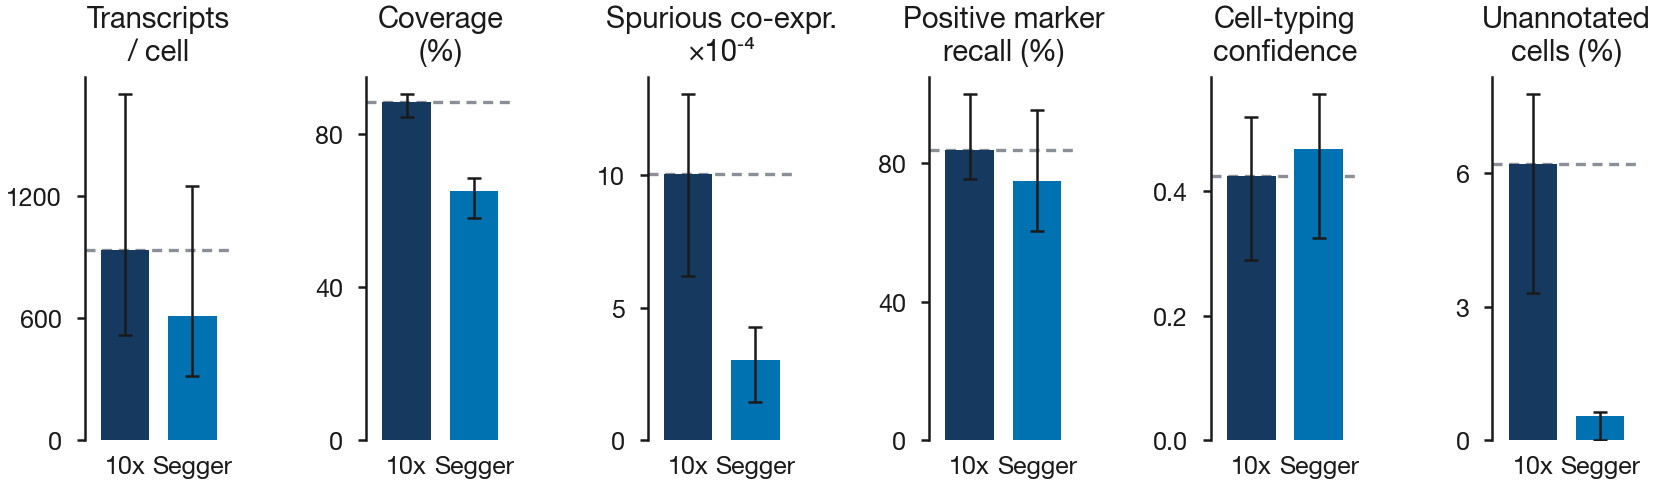

In [14]:
table = pd.DataFrame(summary).T.loc[["10x Cell", "Segger"]]
panels = [
    ("tx_per_cell", 1, "Transcripts\n/ cell"), ("coverage", 1, "Coverage\n(%)"), ("spurious", 1e4, "Spurious co-expr.\n×10⁻⁴"),
    ("pmr", 1, "Positive marker\nrecall (%)"), ("confidence", 1, "Cell-typing\nconfidence"), ("unannotated", 1, "Unannotated\ncells (%)"),
]
fig, axes = plt.subplots(1, 6, figsize=(170 * MM, 40 * MM), gridspec_kw={"wspace": 0.9})
for ax, (key, scale, title) in zip(axes, panels):
    sg.pl.benchmark.bars(ax, table[key] * scale, table[f"{key}_q1"] * scale, table[f"{key}_q3"] * scale, title=title,
                         reference="10x Cell", labels={"10x Cell": "10x"}, rotation=0)
sg.pl.save_panel(fig, OUT_DIR / "panel_c")

## Panel b: UMAPs

The UMAP of each segmentation's typed cells.
With `PAPER_LABELS`, cells are coloured by the display types of the paper, which split the squamous epithelium into basal, intermediate and superficial strata (`cell_types_v2.parquet`); otherwise by the cluster names above.
The silhouette printed on each map is that of the separation above, computed in curated-marker space with nuclear labels, not on the coordinates shown.

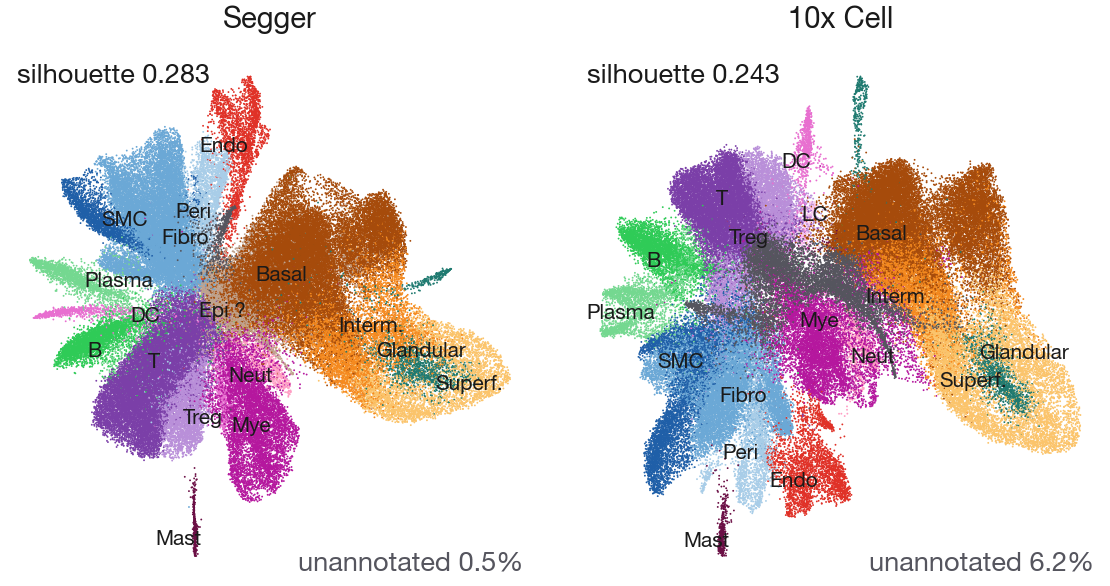

In [15]:
TYPE_COLORS = {
    "Epi_Basal": "#a64b0b", "Epi_Intermediate": "#f58a1f", "Epi_Superficial": "#fbc46b", "Epi_Glandular": "#1f7a70",
    "Epi_Unresolved": "#c0a38e", "Epithelial_Squamous": "#a64b0b", "Epithelial_Glandular": "#1f7a70",
    "Fibroblast": "#6ba8d6", "SmoothMuscle": "#1f5fa8", "Pericyte": "#a8cde8", "Endothelial": "#e03127", "LymphaticEndo": "#ff6a5c",
    "Tcell": "#7b3fa8", "Treg": "#b98fd9", "NK": "#4a1d6e", "Bcell": "#2fcb57", "Plasma": "#74d890", "Myeloid": "#b5179e",
    "DC": "#e86fd0", "Langerhans": "#f9c2ec", "Mast": "#6b0f45", "Neutrophil": "#ff9ec4", "Unknown": "#55555e",
}
SHORT = {
    "Epi_Basal": "Basal", "Epi_Intermediate": "Interm.", "Epi_Superficial": "Superf.", "Epi_Glandular": "Glandular",
    "Epi_Unresolved": "Epi ?", "Epithelial_Squamous": "Squamous", "Epithelial_Glandular": "Glandular", "Fibroblast": "Fibro",
    "SmoothMuscle": "SMC", "Pericyte": "Peri", "Endothelial": "Endo", "LymphaticEndo": "Lymph", "Tcell": "T", "Bcell": "B",
    "Myeloid": "Mye", "Langerhans": "LC", "Neutrophil": "Neut",
}
if PAPER_LABELS:
    display = pl.read_parquet(paths["cell_types"] / "cell_types_v2.parquet", columns=["method", "cell_id", "sctype_v2"]).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(120 * MM, 58 * MM), gridspec_kw={"wspace": 0.08})
for ax, method, key in zip(axes, ("Segger", "10x Cell"), ("segger", "tenx")):
    t = typing[method].query("n_counts >= 50 and n_genes >= 3")
    if PAPER_LABELS:
        label = t["cell_id"].map(display[display["method"] == key].set_index("cell_id")["sctype_v2"]).fillna("Unknown").to_numpy()
    else:
        label = t["cell_type_score_gate"].to_numpy()
    order = np.argsort(label != "Unknown", kind="stable")[::-1]
    ax.scatter(t["umap1"].to_numpy()[order], t["umap2"].to_numpy()[order], s=0.2, c=pd.Series(label[order]).map(TYPE_COLORS).to_numpy(), linewidths=0, rasterized=True)
    names = [(name, group) for name, group in t.groupby(label) if name != "Unknown" and len(group) >= 60]
    texts = [ax.text(g["umap1"].median(), g["umap2"].median(), SHORT.get(name, name), ha="center", va="center", fontsize=5) for name, g in names]
    adjust_text(texts, ax=ax, expand=(1.05, 1.2))
    ax.set_title(method)
    ax.text(0.02, 0.98, f"silhouette {separation[method]['silhouette']:.3f}", transform=ax.transAxes, va="top")
    ax.text(0.98, 0.02, f"unannotated {summary[method]['unannotated']:.1f}%", transform=ax.transAxes, ha="right", color=TYPE_COLORS["Unknown"])
    ax.set_axis_off()
sg.pl.save_panel(fig, OUT_DIR / "panel_b")

## Panel a: whole section, three fields and removed contamination

Left, every Segger cell, coloured by display type (`PAPER_LABELS`) or by the fraction of its 10x transcripts that Segger keeps.
Right, three 430 µm fields: transcripts kept by Segger coloured by the type of their cell, removed transcripts grey.
Without `PAPER_LABELS`, the cells of the fields are typed here by cosine similarity to the profiles of the pseudo-reference.
Next to each field, a 52 µm zoom with the removed transcripts whose gene is a curated marker of a lineage other than that of the cell that would have held them (strata and subtypes collapsed to lineages).
Fields and zooms are those of the paper; each zoom sits where this cross-lineage removal is densest in its field.

,transcripts kept,cross-type removals in the zoom
Muscular vessel wall,265512,77
Immune island in tumour,889307,88
Tertiary lymphoid structure,1188305,184


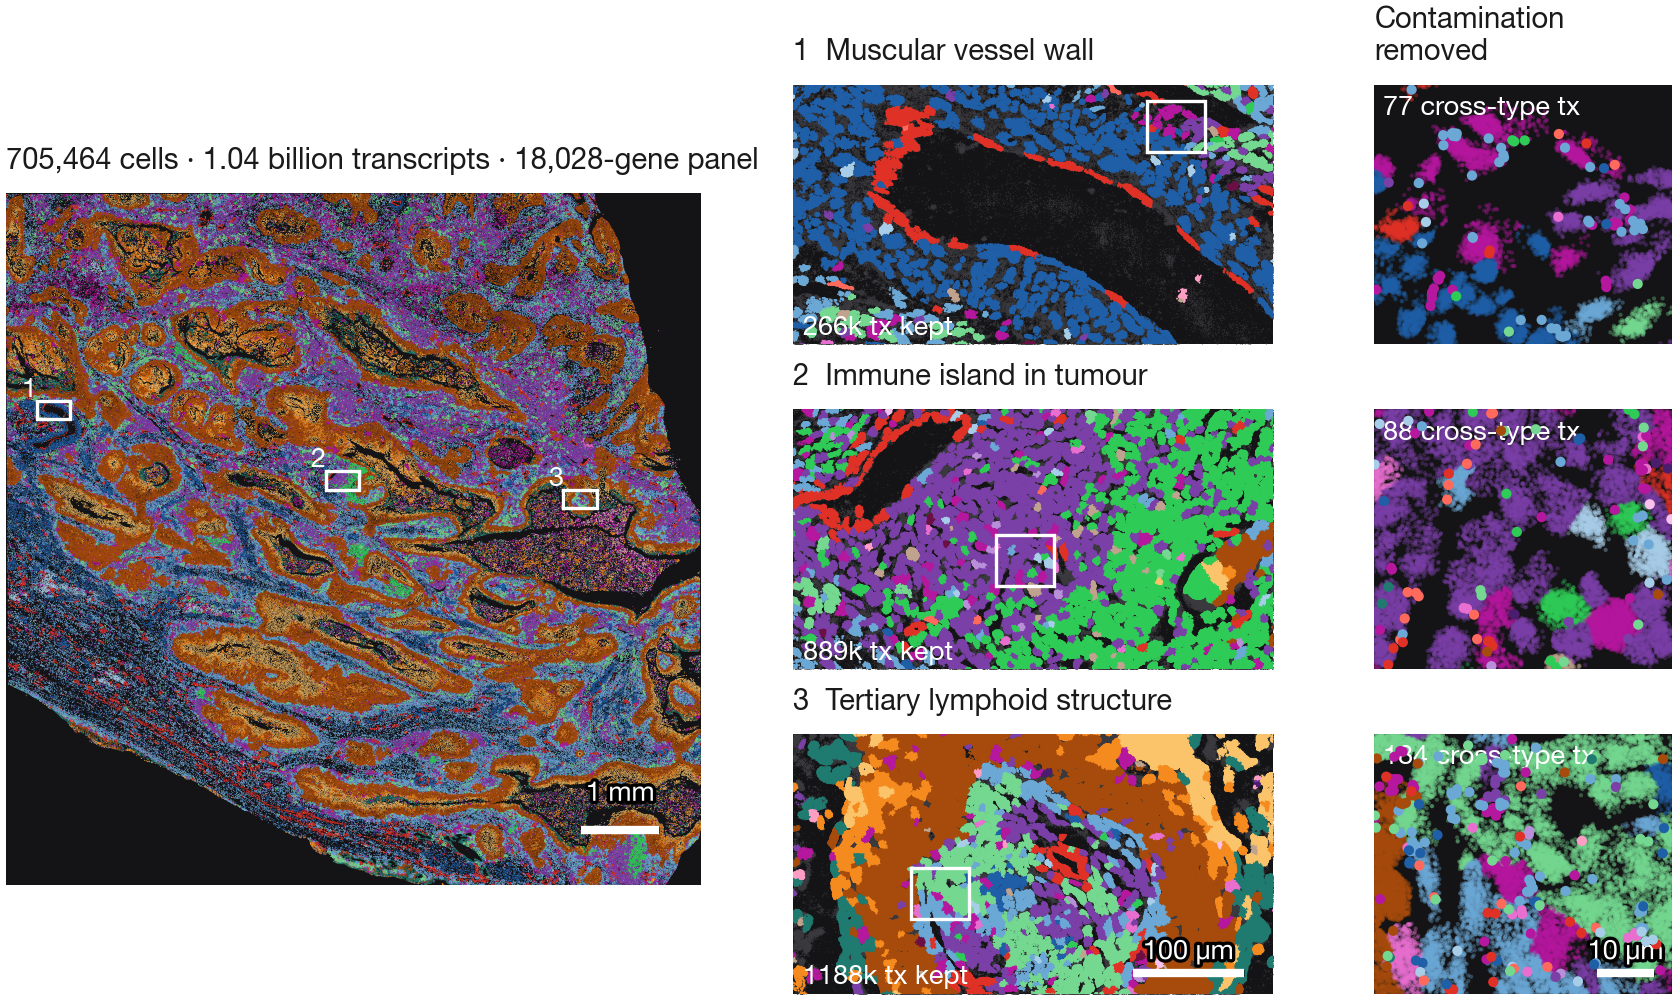

In [16]:
FIELDS = [
    {"title": "Muscular vessel wall", "center": (610.8, 2794.3), "zoom": (739.3193359375, 2715.53125)},
    {"title": "Immune island in tumour", "center": (4321.0, 3694.0), "zoom": (4313.4326171875, 3712.753662109375)},
    {"title": "Tertiary lymphoid structure", "center": (7370.0, 3930.0), "zoom": (7286.83544921875, 3956.255126953125)},
]
FIELD_SIZE, ZOOM_SIZE = (430.0, 232.91666666666666), (52.0, 45.36912751677852)
LINEAGE = {
    "Epi_Basal": "Epi", "Epi_Intermediate": "Epi", "Epi_Superficial": "Epi", "Epi_Glandular": "Epi", "Epi_Unresolved": "Epi",
    "Epithelial_Squamous": "Epi", "Epithelial_Glandular": "Epi", "Tcell": "T", "Treg": "T", "NK": "T", "Bcell": "B", "Plasma": "B",
    "Myeloid": "Mye", "DC": "Mye", "Langerhans": "Mye", "Mast": "Mye", "Neutrophil": "Mye", "Fibroblast": "Fib",
    "SmoothMuscle": "Mural", "Pericyte": "Mural", "Endothelial": "Vasc", "LymphaticEndo": "Vasc",
}
marker_type = wta.exclusive_markers()


def box(center, size):
    return (center[0] - size[0] / 2, center[1] - size[1] / 2, center[0] + size[0] / 2, center[1] + size[1] / 2)


def inside(df, b):
    return df[(df.x_location >= b[0]) & (df.x_location < b[2]) & (df.y_location >= b[1]) & (df.y_location < b[3])]


field_boxes = [box(f["center"], FIELD_SIZE) for f in FIELDS]
crop = wta.crop(TRANSCRIPTS, SEGGER, field_boxes, thresholds).to_pandas()
if PAPER_LABELS:
    v3 = pl.read_parquet(paths["cell_types"] / "cell_types_v3.parquet", columns=["method", "cell_id", "sctype_v3"]).filter(pl.col("method") == "segger")
    cell_type = dict(zip(v3["cell_id"].to_list(), v3["sctype_v3"].to_list()))
else:
    kept = crop[crop["keep"] & crop["feature_name"].isin(column)]
    field_cells = pd.Index(kept["segger_cell_id"].unique())
    X_field = sparse.csr_matrix((np.ones(len(kept)), (field_cells.get_indexer(kept["segger_cell_id"]), kept["feature_name"].map(column).to_numpy())), shape=(len(field_cells), len(ref_genes)))
    field_type, _ = wta.cosine_types(X_field, profiles)
    cell_type = dict(zip(field_cells, np.asarray(types)[field_type]))
crop["host"] = crop["segger_cell_id"].map(cell_type)
crop["type"] = crop["host"].where(crop["keep"])
gene_lineage = crop["feature_name"].map(marker_type).map(lambda t: LINEAGE.get(t, t) if isinstance(t, str) else None)
crop["cross"] = ~crop["keep"] & crop["host"].notna() & gene_lineage.notna() & (gene_lineage != crop["host"].map(lambda t: LINEAGE.get(t, t)))

overview = cell_tables["argmax_q30"].filter(pl.col("n") >= 20).with_columns(x=pl.col("sx") / pl.col("n"), y=pl.col("sy") / pl.col("n"))
overview = overview.join(cell_tables["kept"].rename({"n": "kept"}), on="segger_cell_id", how="left").join(
    cell_tables["tenx"].rename({"cell_id": "segger_cell_id", "n": "tenx"}), on="segger_cell_id", how="left").to_pandas()

fig = plt.figure(figsize=(183 * MM, 100 * MM))
grid = fig.add_gridspec(3, 3, width_ratios=[2.2, 1.9, 1.0], wspace=0.06, hspace=0.25)
ax = fig.add_subplot(grid[:, 0])
if PAPER_LABELS:
    colors = overview["segger_cell_id"].map(cell_type).map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"])
    ax.scatter(overview["x"], overview["y"], s=0.05, c=colors, linewidths=0, rasterized=True)
else:
    kept_share = (overview["kept"] / overview["tenx"]).fillna(0).clip(0, 1)
    points = ax.scatter(overview["x"], overview["y"], s=0.05, c=kept_share, cmap="magma", vmin=0.3, vmax=1, linewidths=0, rasterized=True)
    fig.colorbar(points, ax=ax, fraction=0.03, pad=0.01, label="share of 10x transcripts kept")
fov.tile(ax, (overview["x"].min(), overview["y"].min(), overview["x"].max(), overview["y"].max()), background="#141416")
ax.set_title(f"{len(overview):,} cells · {n_scored / 1e9:.2f} billion transcripts · {len(genes):,}-gene panel", loc="left")
fov.scale_bar(ax, 1000, "1 mm")
for i, (field, b) in enumerate(zip(FIELDS, field_boxes)):
    fov.box(ax, b, color="white")
    ax.text(b[0], b[1], str(i + 1), color="white", ha="right", va="bottom")
    c = inside(crop, b)
    axf = fig.add_subplot(grid[i, 1])
    fov.tile(axf, b, background="#141416")
    axf.scatter(c.x_location[c.type.isna()], c.y_location[c.type.isna()], s=0.1, c="#3c3c40", alpha=0.35, linewidths=0, rasterized=True)
    shown = c[c.type.notna()]
    axf.scatter(shown.x_location, shown.y_location, s=0.22, c=shown.type.map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"]), linewidths=0, rasterized=True)
    zb = box(field["zoom"], ZOOM_SIZE)
    fov.box(axf, zb, color="white")
    axf.set_title(f"{i + 1}  {field['title']}", loc="left")
    axf.text(0.02, 0.04, f"{int(c.keep.sum()) / 1000:.0f}k tx kept", transform=axf.transAxes, color="white")
    z = inside(c, zb)
    axz = fig.add_subplot(grid[i, 2])
    fov.tile(axz, zb, background="#141416")
    axz.scatter(z.x_location[z.type.notna()], z.y_location[z.type.notna()], s=1.0, c=z.type[z.type.notna()].map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"]), alpha=0.35, linewidths=0)
    cross = z[z.cross]
    axz.scatter(cross.x_location, cross.y_location, s=6, c=cross.feature_name.map(marker_type).map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"]), linewidths=0, zorder=5)
    axz.text(0.03, 0.96, f"{int(z.cross.sum())} cross-type tx", transform=axz.transAxes, color="white", va="top")
    if i == 0:
        axz.set_title("Contamination\nremoved", loc="left")
fov.scale_bar(axf, 100)
fov.scale_bar(axz, 10)
sg.pl.save_panel(fig, OUT_DIR / "panel_a")
pd.DataFrame({"transcripts kept": [int(inside(crop, b).keep.sum()) for b in field_boxes],
              "cross-type removals in the zoom": [int(inside(crop, box(f["zoom"], ZOOM_SIZE)).cross.sum()) for f in FIELDS]},
             index=[f["title"] for f in FIELDS])

## Software versions

In [17]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # deprecation notices raised while reading package versions
    print(sc.logging.print_header())

pandas	2.2.3
matplotlib	3.10.1
numpy	2.2.5
polars	1.44.2
scanpy	1.11.4
adjustText	1.3.0
scipy	1.15.2
----	----
shapely	2.1.0
zarr	2.18.7
pycparser	2.22
comm	0.2.2
tornado	6.4.2
polars-runtime-32	1.44.2
defusedxml	0.7.1
cffi	1.17.1
Deprecated	1.2.18
certifi	2025.1.31 (2025.01.31)
numba	0.61.2
h5py	3.13.0
typing_extensions	4.13.2
pure_eval	0.2.3
tqdm	4.67.1
fonttools	4.57.0
jupyter_client	8.6.3
prompt_toolkit	3.0.51
debugpy	1.8.14
zipp	4.1.0
pyzmq	26.4.0
psutil	7.0.0
parso	0.8.4
charset-normalizer	3.4.1
ipykernel	6.29.5
pyparsing	3.2.3
legacy-api-wrap	1.4.1
scikit-learn	1.5.2
python-dateutil	2.9.0.post0
PyYAML	6.0.2
scikit-image	0.26.0
platformdirs	4.3.7
packaging	25.0
rtree	1.4.0
ipython	9.1.0
igraph	0.11.8
joblib	1.4.2
Pygments	2.19.1
anndata	0.11.4
matplotlib-inline	0.1.7
texttable	1.7.0
lazy-loader	0.6
session-info2	0.1.2
executing	2.2.0
importlib_metadata	9.0.1
geopandas	1.0.1
Jinja2	3.1.6
numcodecs	0.15.1
leidenalg	0.10.2
pillow	11.2.1
cloudpickle	3.1.2
statsmodels	0.15.0
natsort	8